# Atividade — K-Means com padronização

Nesta atividade, você aplicará K-Means com padronização e analisará como a escala das variáveis altera os agrupamentos.

**Base:** `clientes_comportamento_kmeans.csv`

> Não use `cliente_id` nem `perfil_referencia` no treinamento. A referência será usada apenas no fim, para avaliar o agrupamento.

## 1. Bibliotecas

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

SEMENTE = 42

In [10]:
from sklearn.preprocessing import StandardScaler

## 2. Leitura e inspeção

Carregue o CSV. Exiba as cinco primeiras linhas, dimensões, tipos, valores ausentes e estatísticas descritivas.

In [11]:
# TODO: leia clientes_comportamento_kmeans.csv
df = pd.read_csv("clientes_comportamento_kmeans.csv")
display(df.head())

,cliente_id,renda_anual,compras_mes,ticket_medio,tempo_site_min,taxa_cliques_pct,perfil_referencia
0,CLI104,74392,4.8,236.46,48.2,41.0,alto_engajamento
1,CLI129,128069,4.4,187.81,47.6,38.0,alto_engajamento
2,CLI062,34308,8.1,141.93,17.6,17.5,recorrente
3,CLI014,100463,1.9,76.71,25.6,15.0,explorador
4,CLI057,115215,9.2,139.15,21.2,27.2,recorrente


## 3. Preparação com padronização

In [12]:
# TODO: selecione as colunas numéricas em X
colunas = ["renda_anual", "compras_mes", "ticket_medio", "tempo_site_min", "taxa_cliques_pct"]
X = df[colunas]

# TODO: crie StandardScaler e use fit_transform
scaler = StandardScaler()
X_modelo = scaler.fit_transform(X)

## 4. Escolha de K

Teste K de 2 a 6. Para cada valor, registre a inércia e a silhueta; depois faça um gráfico para cada métrica.

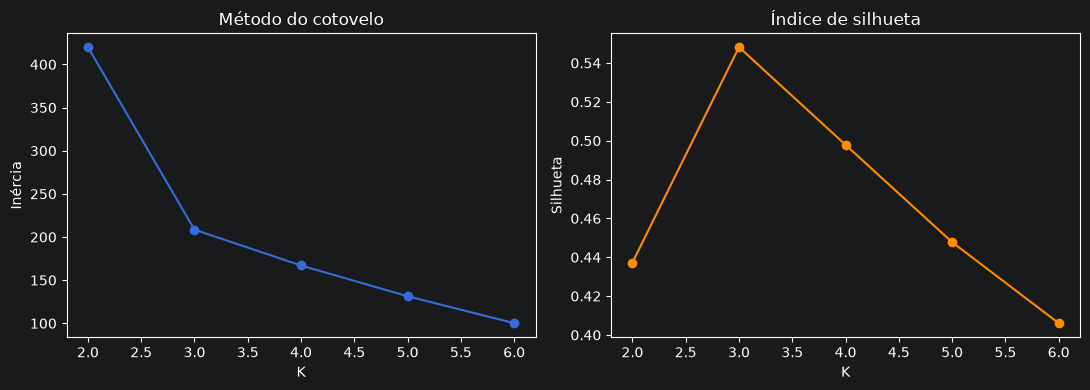

In [13]:
# TODO: complete o teste
valores_k = range(2, 7)
inercias, silhuetas = [], []
for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    grupos = modelo.fit_predict(X_modelo)
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(X_modelo, grupos))

# TODO: desenhe os gráficos
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(list(valores_k), inercias, marker="o")
eixos[0].set(title="Método do cotovelo", xlabel="K", ylabel="Inércia")
eixos[1].plot(list(valores_k), silhuetas, marker="o", color="darkorange")
eixos[1].set(title="Índice de silhueta", xlabel="K", ylabel="Silhueta")
plt.tight_layout()
plt.show()

## 5. Modelo final

Treine K=3, acrescente `cluster` ao DataFrame e mostre as médias das variáveis por cluster.

In [14]:
# TODO: treine o K-Means final
kmeans = KMeans(n_clusters=3, random_state=SEMENTE, n_init=10)
clusters = kmeans.fit_predict(X_modelo)
df["cluster"] = clusters
resumo = df.groupby("cluster")[colunas].mean().round(2)
display(resumo)

,renda_anual,compras_mes,ticket_medio,tempo_site_min,taxa_cliques_pct
cluster,,,,,
0,99379.38,2.22,75.77,30.57,11.92
1,94342.02,8.99,132.54,17.14,24.43
2,98551.06,5.17,212.51,45.75,39.29


## 6. Visualização

Crie dois gráficos de dispersão: `renda_anual × compras_mes` e `tempo_site_min × taxa_cliques_pct`, colorindo pelos clusters.

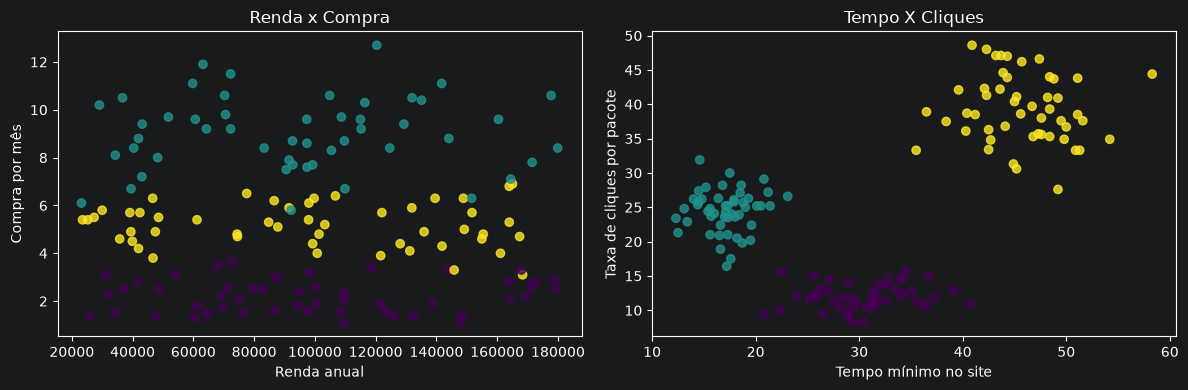

In [17]:
# TODO: crie uma figura com dois subgráficos
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
eixos[0].scatter(df["renda_anual"], df["compras_mes"], c=clusters, cmap="viridis", alpha=0.8)
eixos[0].set(xlabel="Renda anual", ylabel="Compra por mês", title="Renda x Compra")
eixos[1].scatter(df["tempo_site_min"], df["taxa_cliques_pct"], c=clusters, cmap="viridis", alpha=0.8)
eixos[1].set(xlabel="Tempo mínimo no site", ylabel="Taxa de cliques por pacote", title="Tempo X Cliques")
plt.tight_layout()
plt.show()

## 7. Avaliação externa

Somente agora compare `perfil_referencia` com os clusters usando tabela cruzada e ARI.

In [16]:
# TODO: tabela cruzada e adjusted_rand_score
tabela = pd.crosstab(df["perfil_referencia"], df["cluster"], rownames=["referencia"], colnames=["cluster"])

ari = adjusted_rand_score(df["perfil_referencia"], clusters)
display(tabela)
print(f"ARI: {ari:.4f}")

cluster,0,1,2
referencia,,,
alto_engajamento,0,0,50
explorador,50,0,0
recorrente,0,50,0


ARI: 1.0000


## 8. Conclusão

Responda: qual K parece adequado? Qual variável mais influenciou o resultado? Os clusters representam os perfis comportamentais? O que você espera que mude ao executar a outra versão da atividade?